# 선형 회귀 (Linear Regression)
- 변수 간의 관계를 찾는 통계 기법

## 데이터가 있다고 하자.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

In [9]:
import pandas as pd

data = {
    "평수": [10, 15, 20, 25, 30, 35, 40, 45, 50],
    "집값(만원)": [5000, 7000, 10000, 15000, 19000, 20000, 24000, 29000, 33000]
}

df = pd.DataFrame(data)
print(df)

   평수  집값(만원)
0  10    5000
1  15    7000
2  20   10000
3  25   15000
4  30   19000
5  35   20000
6  40   24000
7  45   29000
8  50   33000


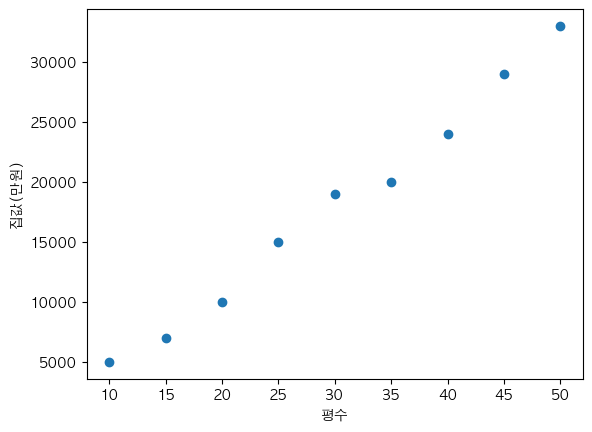

In [10]:
plt.scatter(df["평수"], df["집값(만원)"])
plt.xlabel("평수")
plt.ylabel("집값(만원)")
plt.show()

## 데이터의 관계를 제일 잘 나타내는 최적의 선은 무엇일까?
- $y^{'} = wx + b$로 나타낼 수 있을 것이다.
- 이때 $x$는 입력, $w$는 가중치, $b$는 편향이라고 한다.
- 입력 $x$는 이미 주어져 있으므로 우리는 $w$와 $b$를 구하는 방법에 대해 학습한다.

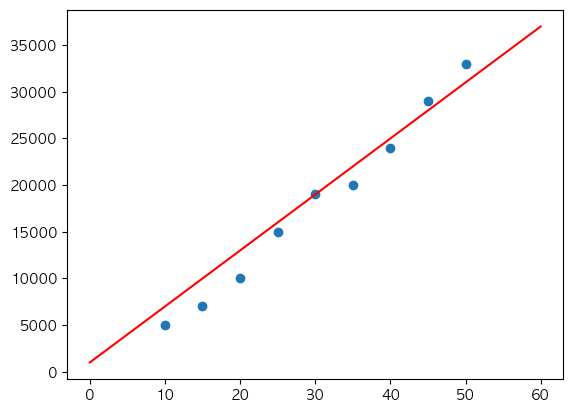

In [ ]:
x = np.linspace(0, 60, 100)  
y = 600 * x + 1000            

plt.plot(x, y, color="red")   
plt.scatter(df["평수"], df["집값(만원)"])  
plt.show()

## 데이터가 여러 개라면?
- 집 값에 대한 데이터가 여러 개가 주어질 수 있다.
- 예를 들어 평수, 위치, 층수 등등
- 이 때는 $y^{'} = w_{1}x_{1} + w_{2}x_{2} + \cdots + w_{k}x_{k} + w_{0}$로 함수를 표현할 수 있으며 우리가 찾아야할 가중치가 늘어난다.

# 손실 함수
- 손실 함수는 예측값과 실제값의 차이를 측정하기 위해 사용한다.
- 손실 함수의 값을 줄이는 방향으로 가는 것이 목표이다.

| 손실 함수 | 수식 | 특징 |
| --- | --- | --- |
| $L_{1}$ | $\sum_{i=1}^{n} \lvert y-\hat{y} \rvert$ | 이상치에 덜 민감, 합계라 비교 어려움 |
| $MAE$ | $\frac{1}{N} \sum_{i=1}^{n} \lvert y-\hat{y} \rvert$ | L1의 평균, 해석이 직관적 |
| $L_{2}$ | $\sum_{i=1}^{n} (y - \hat{y})^2$ | 큰 오차에 큰 페널티, 이상치에 민감 |
| $MSE$ | $\frac{1}{N} \sum_{i=1}^{n} (y - \hat{y})^2$ | 가장 많이 사용, 경사하강법에 유리 |
| $RMSE$ | $\sqrt{\frac{1}{N} \sum_{i=1}^{n} (y - \hat{y})^2}$ | 단위가 원래 데이터와 같아 실무에서 선호 |


# 경사하강법
손실함수의 값이 가장 작아지는 방향으로 조금씩 이동하며 최적의 값을 찾는 방법
MSE를 예로 들면 이차함수 형태에서 오른쪽은 기울기가 양수, 왼쪽은 기울기가 음수이다.

이 때 기울기에 반대 방향으로 파라미터를 조정한다면 손실이 작아지는 방향으로 이동할 수 있다.
하지만 너무 큰 값으로 조정하게 된다면 역효과가 날 수 있기에 학습률을 사용하여 학습 속도를 조절한다.

$$w_{t+1} = w_{t} - \alpha * \frac{dL}{dw}$$

## 손실함수의 모양

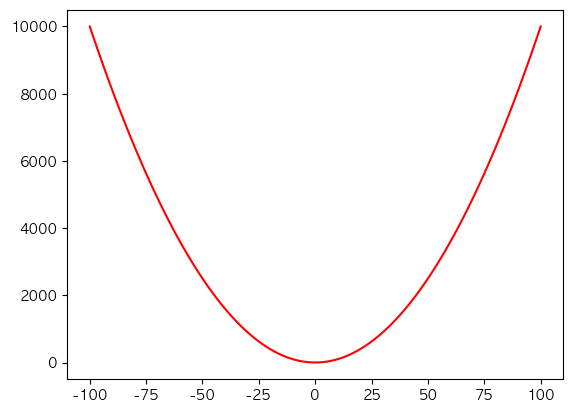

In [15]:
x = np.linspace(-100, 100, 100)
y = x ** 2

plt.plot(x, y, 'red')

## 경사하강법 코드

Text(0, 0.5, 'Loss')

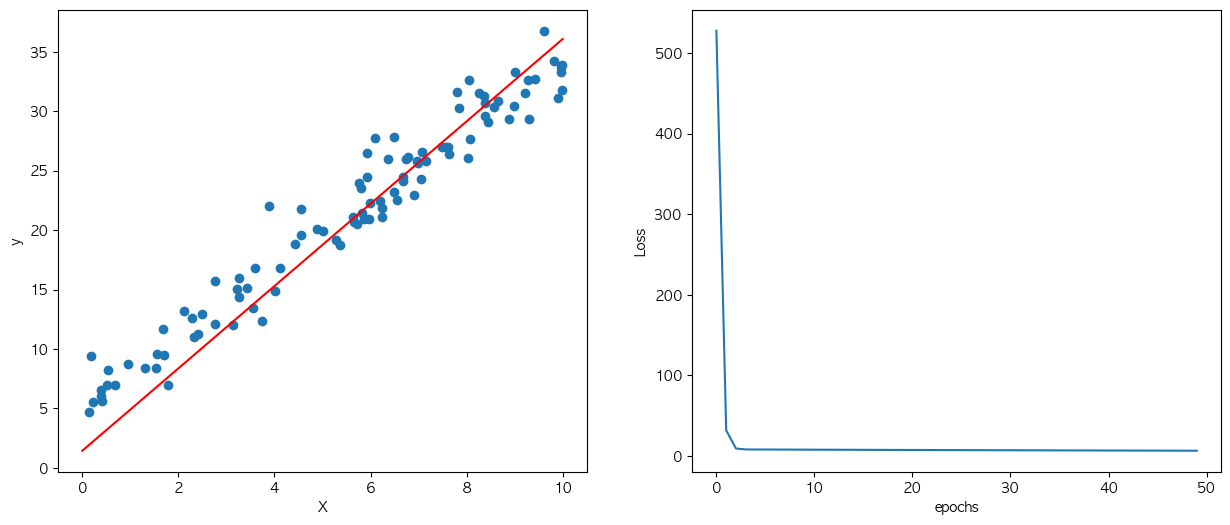

In [35]:
# 데이터 생성
X = np.random.rand(100) * 10
y = 3 * X + 5 + np.random.randn(100) * 2  # y = 3x + 5 + 노이즈

# 경사하강법 함수 정의
def gradient_descent(X, y, epochs, lr):
    w, b = 0.0, 0.0
    n = len(X)
    loss_history = []

    for epoch in range(epochs):
        pred = w * X + b
        dw = -2 * (1/n) * np.sum(X * (y - pred))
        db = -2 * (1/n) * np.sum(y - pred)
        w -= lr * dw
        b -= lr * db
        loss = np.mean((y-pred) ** 2)
        loss_history.append(loss)
    return w, b, loss_history

w, b, loss_history = gradient_descent(X, y, 50, 0.01)

x = np.linspace(0, 10, 100)
y_pred = w * x + b

fig, axes = plt.subplots(1, 2, figsize = (15, 6))
axes[0].scatter(X, y)
axes[0].plot(x, y_pred, 'red')
axes[0].set_xlabel("X")
axes[0].set_ylabel("y")

axes[1].plot(loss_history)
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("Loss")



# 하이퍼파라미터
하이퍼파라미터는 학습을 제어하며 사람이 직접 설정해야 하는 파라미터이다.
대표적으로는 학습률, 에포크, 배치 등이 있다.

어떠한 하이퍼파라미터도 이상적인 값은 없으며 풀어야되는 문제에 따라 적당한 값을 적용하면 된다.

## 학습률
경사하강법의 기울기 앞에 곱해지는 $\alpha$로 학습의 속도를 조절한다.

학습률이 너무 작다면 손실이 가장 작은 곳까지 가는 시간이 오래 걸릴 것이고 반대로 너무 크다면 손실이 가장 작은 곳으로 가는 것이 아니라 발산 할 수도 있다.

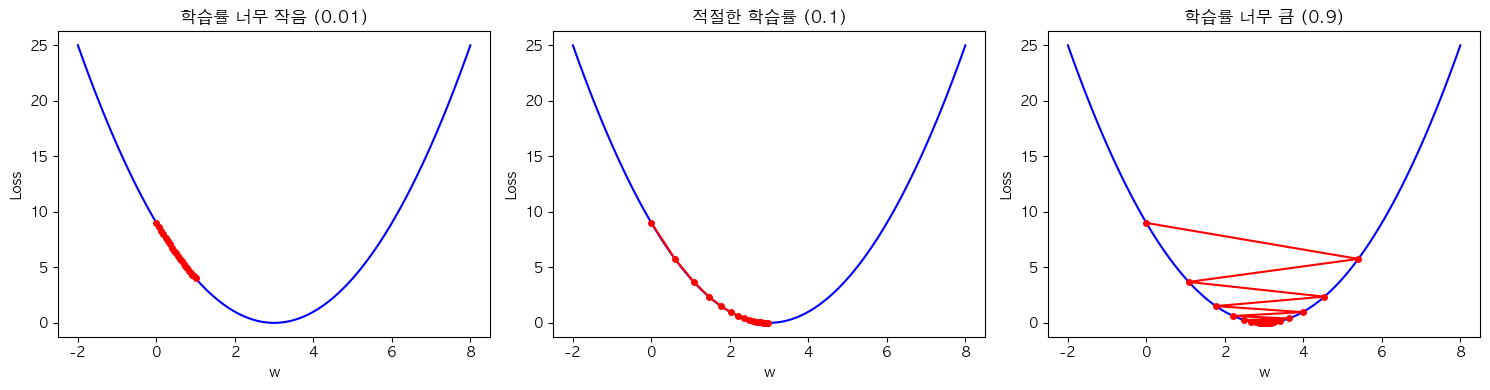

In [16]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 손실 함수: L(w) = (w - 3)^2 → 최저점은 w = 3
def loss(w):
    return (w - 3) ** 2

def gradient(w):
    return 2 * (w - 3)

w_values = np.linspace(-2, 8, 100)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, lr, title in zip(axes, [0.01, 0.1, 0.9], ["학습률 너무 작음 (0.01)", "적절한 학습률 (0.1)", "학습률 너무 큼 (0.9)"]):
    w = 0  # 시작점
    history = [w]
    
    for _ in range(20):
        w = w - lr * gradient(w)
        history.append(w)
    
    ax.plot(w_values, loss(w_values), 'b-')
    ax.plot(history, [loss(w) for w in history], 'ro-', markersize=4)
    ax.set_title(title)
    ax.set_xlabel("w")
    ax.set_ylabel("Loss")

plt.tight_layout()
plt.show()



## 배치
경사하강법을 계산할 때 전체 데이터를 한번에 RAM에 올려야 한다.
하지만 데이터가 크다면 Out of Memory가 발생할 수도 있기 때문에 배치 경사하강법을 사용한다.
| 종류 | 방법 | 장단점 |
| --- | --- | --- | 
| Batch GD | 전체 데이터 당 한 번 파라미터를 업데이트 | 안정적이고 부드럽게 수렴하지만 데이터가 크면 메모리 부족 |
| SGD | 데이터 하나 당 파라미터 업데이트 | 메모리를 적게 사용하며 업데이트가 빠르지만 불안정 |
| Mini-Batch SGD | 데이터 n개 당 파라미터 업데이트 | 메모리와 속도의 균형이 있지만 배치 크기를 직접 정해야한다. |

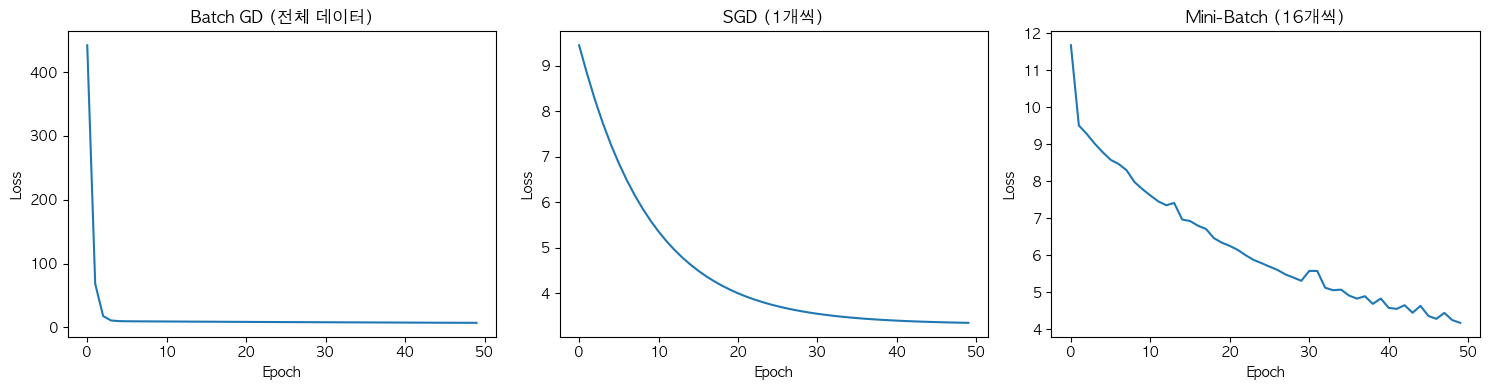

In [17]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

# 샘플 데이터 생성
X = np.random.rand(100) * 10
y = 3 * X + 5 + np.random.randn(100) * 2  # y = 3x + 5 + 노이즈

# 경사하강법 함수
def gradient_descent(X, y, lr=0.01, epochs=50, batch_size=None):
    w, b = 0.0, 0.0
    n = len(X)
    loss_history = []
    
    for epoch in range(epochs):
        if batch_size is None:  # Batch GD (전체 데이터)
            pred = w * X + b
            dw = -(2/n) * np.sum(X * (y - pred))
            db = -(2/n) * np.sum(y - pred)
            w -= lr * dw
            b -= lr * db
            loss = np.mean((y - pred) ** 2)
        elif batch_size == 1:  # SGD (1개씩)
            for i in range(n):
                pred = w * X[i] + b
                dw = -2 * X[i] * (y[i] - pred)
                db = -2 * (y[i] - pred)
                w -= lr * dw
                b -= lr * db
            loss = np.mean((y - (w * X + b)) ** 2)
        else:  # Mini-Batch SGD
            indices = np.random.permutation(n)
            for start in range(0, n, batch_size):
                idx = indices[start:start+batch_size]
                X_batch, y_batch = X[idx], y[idx]
                pred = w * X_batch + b
                dw = -(2/len(idx)) * np.sum(X_batch * (y_batch - pred))
                db = -(2/len(idx)) * np.sum(y_batch - pred)
                w -= lr * dw
                b -= lr * db
            loss = np.mean((y - (w * X + b)) ** 2)
        
        loss_history.append(loss)
    
    return w, b, loss_history

# 3가지 방식 비교
w1, b1, loss1 = gradient_descent(X, y, lr=0.01, epochs=50, batch_size=None)   # Batch GD
w2, b2, loss2 = gradient_descent(X, y, lr=0.001, epochs=50, batch_size=1)     # SGD
w3, b3, loss3 = gradient_descent(X, y, lr=0.005, epochs=50, batch_size=16)    # Mini-Batch

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

titles = ["Batch GD (전체 데이터)", "SGD (1개씩)", "Mini-Batch (16개씩)"]
losses = [loss1, loss2, loss3]

for ax, title, loss in zip(axes, titles, losses):
    ax.plot(loss)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")

plt.tight_layout()
plt.show()

## 에포크
간단히 말하면 데이터셋에 대한 반복 횟수를 뜻한다.
만약 데이터가 128개 있고 배치 크기가 32라면 파라미터가 4번 업데이트 되는 것을 1에포크라고 한다.

에포크가 너무 적다면 손실이 수렴하기 전에 학습을 멈출 것이고 반대로 에포크가 너무 많다면 학습에 시간이 오래 걸릴 것이다.

In [ ]:
np.random.seed(42)

X = np.random.rand(100) * 10
y = 3 * X + 5 + np.random.randn(100) * 2

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, epochs, title in zip(axes, [1, 20, 50], ["1 에포크 (학습 부족)", "20 에포크 (적절)", "50 에포크 (충분)"]):
    w, b = 0.0, 0.0
    n = len(X)
    
    for _ in range(epochs):
        pred = w * X + b
        dw = -(2/n) * np.sum(X * (y - pred))
        db = -(2/n) * np.sum(y - pred)
        w -= 0.001 * dw
        b -= 0.001 * db
    
    ax.scatter(X, y, s=10, alpha=0.5)
    x_line = np.linspace(0, 10, 100)
    ax.plot(x_line, w * x_line + b, 'r-', linewidth=2)
    ax.set_title(f"{title}\nw={w:.2f}, b={b:.2f}")
    ax.set_xlabel("X")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()

# Sklearn으로 선형회귀 구현하기

## 라이브러리 임포트

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes # 당뇨 데이터
from sklearn.metrics import mean_squared_error # MSE Loss
from sklearn.model_selection import train_test_split # 학습 데이터, 테스트 데이터 분리
from sklearn.linear_model import LinearRegression # 선형 회귀

## 데이터 살펴보기

In [40]:
data = load_diabetes()
print(data.keys())

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


In [46]:
df = pd.DataFrame(data.data, columns = data.feature_names)
df['y'] = data.target

df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,y
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


## 학습 데이터, 테스트 데이터 분리
우리가 예측 모델을 만들기 위해서는 데이터를 사용하여 학습시킨다.
학습 이후 테스트를 할 때 우리가 학습된 데이터로 테스트한다면 결과가 잘 나올 수밖에 없을 것이다.

그러므로 데이터를 분리하여 학습 데이터는 학습에 사용하고 테스트 데이터는 마지막에 테스트할 때만 사용한다.
우리는 이를 일반화 성능을 측정한다고 하며 학습은 잘 되었지만 테스트 결과가 좋지 않다면 과적합, 학습도 잘 되지 않고 테스트 결과도 좋지 않다면 과소적합이라 한다.

In [49]:
# 먼저 feature와 target을 분리한다.
X = df.drop("y", axis = 1)
y = df["y"]

# 학습 데이터와 테스트 데이터를 분리한다.(7 : 3)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7)

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(309, 10)
(309,)
(133, 10)
(133,)


## 학습 데이터로 학습

In [56]:
model = LinearRegression()       # 모델 생성

model.fit(X_train, y_train)      # 모델 학습

y_pred = model.predict(X_test)   # 테스트 데이터로 예측

print(f"MSE : {mean_squared_error(y_test, y_pred)}")

MSE : 3422.1743816605185


/Users/kms/Desktop/AI-study/.jupyter/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/kms/Desktop/AI-study/.jupyter/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/kms/Desktop/AI-study/.jupyter/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
